# Severity Classifier — Ugandan Non-Standard Speech
Trains a lightweight wav2vec2-based classifier to predict speech impairment severity (mild / moderate / severe) from raw audio.

**Architecture:** wav2vec2-base (frozen encoder) → mean pool → 2-layer MLP → 3-class softmax  
**Purpose:** Routes each call to the best-matched Whisper model in `modal_streaming_whisper.py`  
**Expected accuracy:** 75–85% on validation set

## Cell 1: Install packages

In [6]:
import subprocess, sys
packages = [
    "huggingface_hub==0.23.4", "datasets==2.19.2",
    "transformers>=4.39.0", "accelerate>=0.30.0",
    "torch", "evaluate", "scikit-learn",
    "soundfile", "librosa", "numpy", "pandas", "matplotlib",
]
print("Installing packages...")
for pkg in packages:
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       capture_output=True, text=True)
    print(f"  {'OK' if r.returncode==0 else 'FAIL'} {pkg}")
print("Done.")

Installing packages...
  OK huggingface_hub==0.23.4
  OK datasets==2.19.2
  OK transformers>=4.39.0
  OK accelerate>=0.30.0
  OK torch
  OK evaluate
  OK scikit-learn
  OK soundfile
  OK librosa
  OK numpy
  OK pandas
  OK matplotlib
Done.


## Cell 2: Imports

In [7]:
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset, Audio, concatenate_datasets
from huggingface_hub import login, hf_hub_download
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix
import librosa
from tqdm import tqdm

warnings.filterwarnings("ignore")
print("Imports OK")
print(f"  PyTorch : {torch.__version__}")
print(f"  CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")

Imports OK
  PyTorch : 2.8.0+cu129
  CUDA    : True
  GPU : Tesla T4


## Cell 3: Settings

In [8]:
HF_TOKEN = os.environ.get("HF_TOKEN", "")

DATASET_NAME   = "cdli/ugandan_english_nonstandard_speech_v1.0"
AUDIO_COL      = "audio"
SPEAKER_COL    = "speaker_id"
AUDIO_LEN_COL  = "audio_length"
SAMPLE_RATE    = 16_000
CLIP_SECONDS   = 8        # use first 8 s for classification
MAX_LENGTH     = SAMPLE_RATE * CLIP_SECONDS

# Label mapping
LABELS     = ["mild", "moderate", "severe"]
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

# wav2vec2 backbone
WAV2VEC_MODEL = "facebook/wav2vec2-base"

# Training
LEARNING_RATE = 1e-4
NUM_EPOCHS    = 30
BATCH_SIZE    = 8
EARLY_STOP    = 5

OUTPUT_DIR = "/jupyter_kernel/trained_models/severity_classifier"
os.makedirs(OUTPUT_DIR, exist_ok=True)

REPO_NAME = "jojo007unfi/whisper-severity-classifier"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device    : {device}")
print(f"Clip size : {CLIP_SECONDS}s ({MAX_LENGTH} samples)")
print(f"Labels    : {LABELS}")

Device    : cuda
Clip size : 8s (128000 samples)
Labels    : ['mild', 'moderate', 'severe']


## Cell 4: HuggingFace login

In [9]:
if not HF_TOKEN:
    HF_TOKEN = input("Paste your HuggingFace token: ").strip()
os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)
print("Logged in.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in.


## Cell 5: Load dataset & build severity labels

In [10]:
PARQUET_FILES = {
    "train": [f"data/train-{str(i).zfill(5)}-of-00008.parquet" for i in range(8)],
    "validation": ["data/validation-00000-of-00001.parquet"],
    "extra": ["data/extra-00000-of-00001.parquet"],
}

print("Downloading parquet shards...")
local_files = {}
for split, files in PARQUET_FILES.items():
    local_files[split] = []
    for fname in files:
        path = hf_hub_download(repo_id=DATASET_NAME, filename=fname,
                               repo_type="dataset", token=HF_TOKEN)
        local_files[split].append(path)
        print(f"  {fname.split('/')[-1]} OK")

raw = load_dataset("parquet", data_files=local_files)

try:
    meta_path    = hf_hub_download(repo_id=DATASET_NAME, filename="speaker_metadata.csv",
                                   repo_type="dataset", token=HF_TOKEN)
    speaker_meta = pd.read_csv(meta_path)
    spk_to_sev   = dict(zip(speaker_meta["speaker_id"].astype(str),
                             speaker_meta["severity_speech_impairment"].astype(str)))
    print(f"Speaker metadata loaded: {len(spk_to_sev)} speakers")
except Exception as e:
    raise RuntimeError(f"Speaker metadata required for classifier: {e}")

full_train = concatenate_datasets([raw["train"], raw["extra"]])
val_ds     = raw["validation"]

if AUDIO_LEN_COL in full_train.column_names:
    full_train = full_train.filter(lambda x: x[AUDIO_LEN_COL] <= 30)
    val_ds     = val_ds.filter(lambda x: x[AUDIO_LEN_COL] <= 30)

full_train = full_train.cast_column(AUDIO_COL, Audio(sampling_rate=SAMPLE_RATE))
val_ds     = val_ds.cast_column(AUDIO_COL,     Audio(sampling_rate=SAMPLE_RATE))

def has_known_severity(ex):
    sev = spk_to_sev.get(str(ex[SPEAKER_COL]), "unknown").lower()
    return any(k in sev for k in LABELS)

full_train = full_train.filter(has_known_severity)
val_ds     = val_ds.filter(has_known_severity)

print(f"Train : {len(full_train):,}  |  Val : {len(val_ds):,}")

# Show distribution
from collections import Counter
def get_sev(ex): return spk_to_sev.get(str(ex[SPEAKER_COL]), "unknown").lower()
train_labels = [next((k for k in LABELS if k in get_sev(ex)), "unknown") for ex in full_train]
print("\nTrain severity distribution:")
for sev, cnt in Counter(train_labels).most_common():
    print(f"  {sev:55s}: {cnt:5d}  ({100*cnt/len(train_labels):.1f}%)")

  train-00000-of-00008.parquet OK
  train-00001-of-00008.parquet OK


data/train-00002-of-00008.parquet:   0%|          | 0.00/377M [00:00<?, ?B/s]

  train-00002-of-00008.parquet OK


data/train-00003-of-00008.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

  train-00003-of-00008.parquet OK


...

Filter:   0%|          | 0/5596 [00:00<?, ? examples/s]

Filter:   0%|          | 0/638 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5592 [00:00<?, ? examples/s]

Filter:   0%|          | 0/638 [00:00<?, ? examples/s]

Train : 5,431  |  Val : 638

Train severity distribution:
  severe                                                 :  2711  (49.9%)
  moderate                                               :  2292  (42.2%)
  mild                                                   :   428  (7.9%)


## Cell 6: Dataset class & DataLoaders

In [11]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC_MODEL)

class SeverityDataset(Dataset):
    """Loads audio clips and returns wav2vec2 inputs + severity label."""

    def __init__(self, hf_dataset, spk_to_sev, label2id, max_length):
        self.data       = hf_dataset
        self.spk_to_sev = spk_to_sev
        self.label2id   = label2id
        self.max_length = max_length
        self.feat_ext   = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC_MODEL)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data[idx]
        audio  = row[AUDIO_COL]
        arr    = audio["array"].astype(np.float32)

        # Clip or pad to MAX_LENGTH
        if len(arr) > self.max_length:
            arr = arr[:self.max_length]
        else:
            arr = np.pad(arr, (0, self.max_length - len(arr)))

        inputs = self.feat_ext(
            arr, sampling_rate=SAMPLE_RATE,
            return_tensors="pt", padding=True,
            max_length=self.max_length, truncation=True,
        )
        input_values = inputs.input_values.squeeze(0)

        sev_str = self.spk_to_sev.get(str(row[SPEAKER_COL]), "unknown").lower()
        label   = next((self.label2id[k] for k in LABELS if k in sev_str), -1)
        return input_values, label


train_dataset = SeverityDataset(full_train, spk_to_sev, LABEL2ID, MAX_LENGTH)
val_dataset   = SeverityDataset(val_ds,     spk_to_sev, LABEL2ID, MAX_LENGTH)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Dataset ready  —  train: {len(train_dataset):,}  val: {len(val_dataset):,}")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Dataset ready  —  train: 5,431  val: 638


## Cell 7: Build classifier model

In [12]:
class SeverityClassifier(nn.Module):
    """
    Lightweight severity classifier:
      wav2vec2-base (frozen) -> mean-pool -> 2-layer MLP -> 3-class softmax
    The encoder is frozen — we only train the classifier head.
    This keeps training fast and avoids overfitting on ~1000 samples.
    """
    def __init__(self, num_labels: int = 3, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.encoder    = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL)
        # Freeze encoder — only train the head
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(768, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_labels),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        # Mean-pool across time to get a fixed-size embedding
        hidden = self.encoder(input_values).last_hidden_state  # (B, T, 768)
        pooled = hidden.mean(dim=1)                            # (B, 768)
        return self.classifier(pooled)                         # (B, num_labels)


clf   = SeverityClassifier(num_labels=NUM_LABELS).to(device)
optim = torch.optim.AdamW(
    [p for p in clf.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=1e-4,
)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=NUM_EPOCHS)
crit  = nn.CrossEntropyLoss()

trainable = sum(p.numel() for p in clf.parameters() if p.requires_grad)
total     = sum(p.numel() for p in clf.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Encoder frozen — training head only.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Trainable params: 230,659 / 94,602,371  (0.2%)
Encoder frozen — training head only.


## Cell 8: Train

Training for up to 30 epochs (patience=5)...



Epoch 01 train: 100%|████████████████████████████████████████████████████████| 679/679 [10:02<00:00,  1.16it/s]
                                                                                                               

  Epoch 01  loss=0.5948  train_acc=75.4%  val_acc=21.8%
    ✓ New best — saved  (val_acc=21.8%)



Epoch 02 train: 100%|████████████████████████████████████████████████████████| 679/679 [10:03<00:00,  1.16it/s]
                                                                                                               

  Epoch 02  loss=0.3005  train_acc=89.8%  val_acc=20.7%


...

  Epoch 16  loss=0.0541  train_acc=98.7%  val_acc=43.9%



Epoch 17 train: 100%|████████████████████████████████████████████████████████| 679/679 [09:57<00:00,  1.17it/s]
                                                                                                               

  Epoch 17  loss=0.0470  train_acc=98.8%  val_acc=52.5%



Epoch 18 train: 100%|████████████████████████████████████████████████████████| 679/679 [09:56<00:00,  1.17it/s]
                                                                                                               

  Epoch 18  loss=0.0424  train_acc=98.8%  val_acc=50.5%
  Early stopping at epoch 18 (no improvement for 5 epochs)

Best val accuracy : 52.5%  at epoch 13


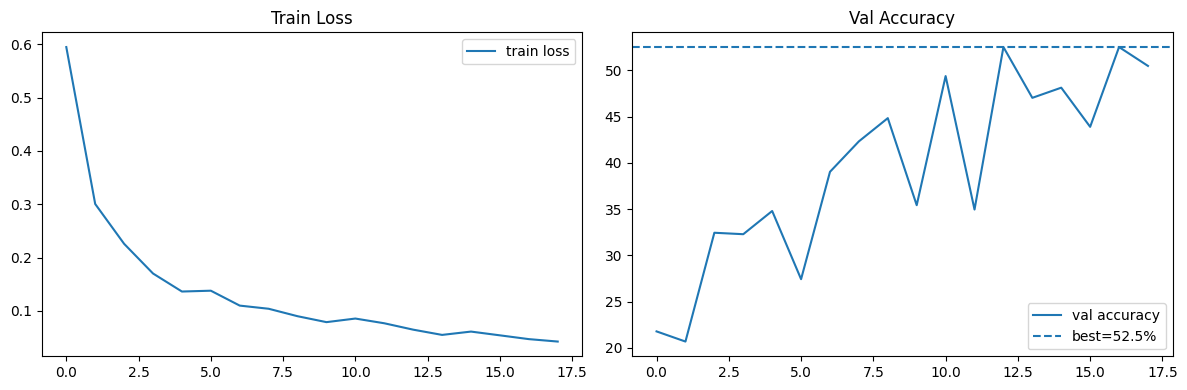

In [13]:
best_acc, best_epoch, no_improve = 0.0, 0, 0
train_losses, val_accs = [], []

print(f"Training for up to {NUM_EPOCHS} epochs (patience={EARLY_STOP})...")

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    clf.train()
    total_loss, correct, n = 0.0, 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        inputs  = inputs.to(device)
        labels  = labels.to(device)
        mask    = labels >= 0    # drop any -1 (unknown severity)
        inputs, labels = inputs[mask], labels[mask]
        if inputs.shape[0] == 0:
            continue
        optim.zero_grad()
        logits = clf(inputs)
        loss   = crit(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(clf.parameters(), 1.0)
        optim.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += inputs.size(0)
    train_acc  = 100 * correct / max(n, 1)
    train_loss = total_loss / max(n, 1)
    train_losses.append(train_loss)

    # ── Validate ────────────────────────────────────────────────────────────
    clf.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs  = inputs.to(device)
            labels  = labels.to(device)
            mask    = labels >= 0
            inputs, labels = inputs[mask], labels[mask]
            if inputs.shape[0] == 0:
                continue
            logits   = clf(inputs)
            correct += (logits.argmax(1) == labels).sum().item()
            n       += inputs.size(0)
    val_acc = 100 * correct / max(n, 1)
    val_accs.append(val_acc)
    sched.step()

    print(f"  Epoch {epoch:02d}  loss={train_loss:.4f}  train_acc={train_acc:.1f}%  val_acc={val_acc:.1f}%")

    if val_acc > best_acc:
        best_acc, best_epoch, no_improve = val_acc, epoch, 0
        torch.save(clf.state_dict(), os.path.join(OUTPUT_DIR, "best_classifier.pt"))
        print(f"    ✓ New best — saved  (val_acc={best_acc:.1f}%)")
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP:
            print(f"  Early stopping at epoch {epoch} (no improvement for {EARLY_STOP} epochs)")
            break

print(f"\nBest val accuracy : {best_acc:.1f}%  at epoch {best_epoch}")

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="train loss"); ax1.set_title("Train Loss"); ax1.legend()
ax2.plot(val_accs, label="val accuracy"); ax2.axhline(best_acc, ls="--", label=f"best={best_acc:.1f}%")
ax2.set_title("Val Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curve.png"), dpi=150); plt.show()

## Cell 9: Evaluate — classification report & confusion matrix


Final eval: 100%|██████████████████████████████████████████████████████████████| 80/80 [00:22<00:00,  3.50it/s]



Classification Report:
              precision    recall  f1-score   support

        mild       0.44      0.43      0.44       234
    moderate       0.47      0.97      0.63       144
      severe       0.83      0.36      0.50       260

    accuracy                           0.53       638
   macro avg       0.58      0.59      0.53       638
weighted avg       0.61      0.53      0.51       638



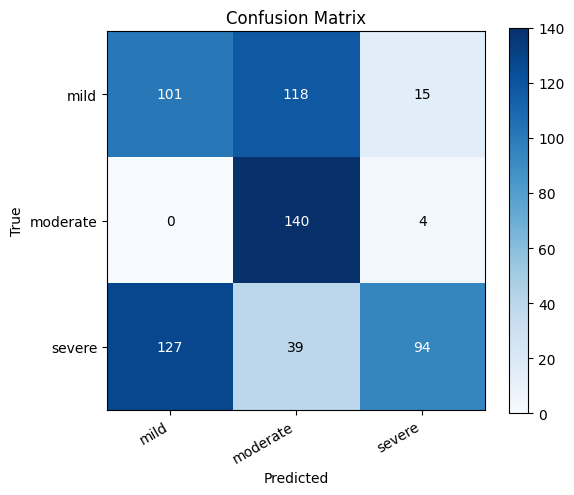

In [14]:
# Load best checkpoint
clf.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_classifier.pt"), map_location=device))
clf.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Final eval"):
        inputs  = inputs.to(device)
        labels  = labels.to(device)
        mask    = labels >= 0
        inputs, labels = inputs[mask], labels[mask]
        if inputs.shape[0] == 0:
            continue
        preds = clf(inputs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=LABELS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(LABELS, rotation=30, ha="right")
ax.set_yticks(range(NUM_LABELS)); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150); plt.show()

## Cell 10: Save & push to HuggingFace Hub

In [15]:
import json as _json

# Save model config alongside weights so Modal can reload it
config = {
    "model_type"  : "severity_classifier",
    "backbone"    : WAV2VEC_MODEL,
    "num_labels"  : NUM_LABELS,
    "label2id"    : LABEL2ID,
    "id2label"    : ID2LABEL,
    "max_length"  : MAX_LENGTH,
    "sample_rate" : SAMPLE_RATE,
    "best_val_acc": round(best_acc, 2),
}
with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    _json.dump(config, f, indent=2)
print(f"Config saved: {config}")

# Push to Hub
from huggingface_hub import HfApi
api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=REPO_NAME, exist_ok=True, private=True, repo_type="model")
api.upload_folder(
    folder_path=OUTPUT_DIR,
    repo_id=REPO_NAME,
    commit_message=f"Severity classifier — val_acc={best_acc:.1f}%",
    token=HF_TOKEN,
)
print(f"\nPushed to: {REPO_NAME}")
print(f"  Best val accuracy : {best_acc:.1f}%")
print(f"  Labels            : {LABELS}")

Config saved: {'model_type': 'severity_classifier', 'backbone': 'facebook/wav2vec2-base', 'num_labels': 3, 'label2id': {'mild': 0, 'moderate': 1, 'severe': 2}, 'id2label': {0: 'mild', 1: 'moderate', 2: 'severe'}, 'max_length': 128000, 'sample_rate': 16000, 'best_val_acc': 52.51}


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Pushed to: jojo007unfi/whisper-severity-classifier
  Best val accuracy : 52.5%
  Labels            : ['mild', 'moderate', 'severe']
